In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import kagglehub
import os

path = kagglehub.dataset_download(
    "sakshamjn/vehicle-detection-8-classes-object-detection"
)

print("Path to dataset files:", path)
print("Folder contents:", os.listdir(path))


Using Colab cache for faster access to the 'vehicle-detection-8-classes-object-detection' dataset.
Path to dataset files: /kaggle/input/vehicle-detection-8-classes-object-detection
Folder contents: ['train']


In [16]:
os.listdir(path + "/train")

['labels', 'labels.npy', 'images']

In [17]:
os.listdir(path + "/train/images")[:5]

['Highway_143_2020-07-30_jpg.rf.a7076f71b722e151bc3533a818aea182.jpg',
 'ulu554_jpg.rf.2e267781b53958af49b1e9ab5f264d9a.jpg',
 'Highway_977_2020-07-30_jpg.rf.36614aa85bf97bac966b4097e475b4a9.jpg',
 'ulu2353_jpg.rf.4343ef0396842f66112639b7604eb643.jpg',
 'Highway_1126_2020-07-30_jpg.rf.d464fc6d9a53e62a2b6b01ade432c627.jpg']

In [18]:
os.listdir(path + "/train/labels")[:5]

['ulu1386_jpg.rf.a5750e969785c5d69b5980d51e7f0b6b.txt',
 'Highway_830_2020-07-30_jpg.rf.bdd5acbefb212b679668e9862841710c.txt',
 'ulu1470_jpg.rf.2330f337e0bb2584c3429ed90c63ab1a.txt',
 'ulu2190_jpg.rf.2182d0a98b9101a7a587570f9b4ab98c.txt',
 'Highway_69_2020-07-30_jpg.rf.49b04efa04d91ffbcf6969510a0b3088.txt']

(np.float64(-0.5), np.float64(387.5), np.float64(387.5), np.float64(-0.5))

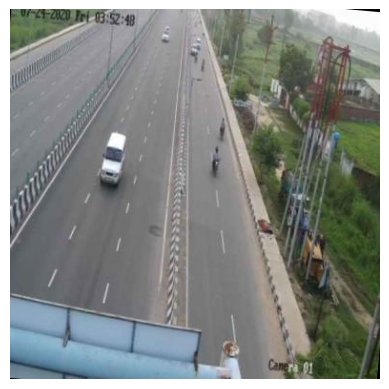

In [19]:
import matplotlib.pyplot as plt
import cv2

img_path = path + "/train/images/" + os.listdir(path + "/train/images")[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")


In [20]:
label_path = path + "/train/labels/" + os.listdir(path + "/train/labels")[0]

with open(label_path, "r") as f:
    print(f.read())


2 0.532452 0.531250 0.098558 0.240385
2 0.719952 0.194712 0.069712 0.096154
4 0.481971 0.155048 0.026442 0.074519



In [21]:
import os
print(os.listdir("/kaggle/input"))


['vehicle-detection-8-classes-object-detection']


In [22]:
import os

DATASET_PATH = "/kaggle/input/vehicle-detection-8-classes-object-detection/train"

print(os.listdir(DATASET_PATH))
print(os.listdir(DATASET_PATH + "/images")[:5])
print(os.listdir(DATASET_PATH + "/labels")[:5])


['labels', 'labels.npy', 'images']
['Highway_143_2020-07-30_jpg.rf.a7076f71b722e151bc3533a818aea182.jpg', 'ulu554_jpg.rf.2e267781b53958af49b1e9ab5f264d9a.jpg', 'Highway_977_2020-07-30_jpg.rf.36614aa85bf97bac966b4097e475b4a9.jpg', 'ulu2353_jpg.rf.4343ef0396842f66112639b7604eb643.jpg', 'Highway_1126_2020-07-30_jpg.rf.d464fc6d9a53e62a2b6b01ade432c627.jpg']
['ulu1386_jpg.rf.a5750e969785c5d69b5980d51e7f0b6b.txt', 'Highway_830_2020-07-30_jpg.rf.bdd5acbefb212b679668e9862841710c.txt', 'ulu1470_jpg.rf.2330f337e0bb2584c3429ed90c63ab1a.txt', 'ulu2190_jpg.rf.2182d0a98b9101a7a587570f9b4ab98c.txt', 'Highway_69_2020-07-30_jpg.rf.49b04efa04d91ffbcf6969510a0b3088.txt']


In [23]:
!ls /content


drive  sample_data


In [24]:
from google.colab import drive
drive.mount('/content/drive')

!ls /content/drive/MyDrive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'Colab Notebooks'


In [25]:
!ls /kaggle/input


vehicle-detection-8-classes-object-detection


In [26]:
!ls /kaggle/input/vehicle-detection-8-classes-object-detection

train


In [27]:
import os, shutil, random


BASE = "/kaggle/input/vehicle-detection-8-classes-object-detection/train"

IMG_DIR = BASE + "/images"
LABEL_DIR = BASE + "/labels"

print("Images:", os.listdir(IMG_DIR)[:5])
print("Labels:", os.listdir(LABEL_DIR)[:5])

OUT = "/kaggle/working/dataset"

for p in ["images/train","images/val","labels/train","labels/val"]:
    os.makedirs(os.path.join(OUT,p), exist_ok=True)

imgs = [f for f in os.listdir(IMG_DIR) if f.endswith((".jpg",".png",".jpeg"))]
random.shuffle(imgs)

s = int(0.8*len(imgs))
train, val = imgs[:s], imgs[s:]

def copy_set(lst, split):
    for img in lst:
        shutil.copy(os.path.join(IMG_DIR,img), os.path.join(OUT,"images",split,img))
        lab = img.rsplit(".",1)[0]+".txt"
        shutil.copy(os.path.join(LABEL_DIR,lab), os.path.join(OUT,"labels",split,lab))

copy_set(train,"train")
copy_set(val,"val")

print("DONE — dataset ")


Images: ['Highway_143_2020-07-30_jpg.rf.a7076f71b722e151bc3533a818aea182.jpg', 'ulu554_jpg.rf.2e267781b53958af49b1e9ab5f264d9a.jpg', 'Highway_977_2020-07-30_jpg.rf.36614aa85bf97bac966b4097e475b4a9.jpg', 'ulu2353_jpg.rf.4343ef0396842f66112639b7604eb643.jpg', 'Highway_1126_2020-07-30_jpg.rf.d464fc6d9a53e62a2b6b01ade432c627.jpg']
Labels: ['ulu1386_jpg.rf.a5750e969785c5d69b5980d51e7f0b6b.txt', 'Highway_830_2020-07-30_jpg.rf.bdd5acbefb212b679668e9862841710c.txt', 'ulu1470_jpg.rf.2330f337e0bb2584c3429ed90c63ab1a.txt', 'ulu2190_jpg.rf.2182d0a98b9101a7a587570f9b4ab98c.txt', 'Highway_69_2020-07-30_jpg.rf.49b04efa04d91ffbcf6969510a0b3088.txt']
DONE — dataset 


Images directory found: /kaggle/input/vehicle-detection-8-classes-object-detection/train/images
Labels directory found: /kaggle/input/vehicle-detection-8-classes-object-detection/train/labels


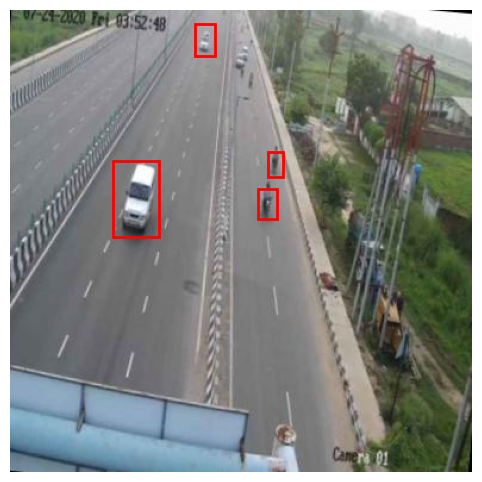

Image file: Highway_143_2020-07-30_jpg.rf.a7076f71b722e151bc3533a818aea182.jpg
Label file: Highway_143_2020-07-30_jpg.rf.a7076f71b722e151bc3533a818aea182.txt


In [28]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Root where Kaggle datasets are mounted
SEARCH_ROOT = "/kaggle"

IMG_DIR = None
LABEL_DIR = None

# Walk through directories to find train/images and train/labels
for root, dirs, files in os.walk(SEARCH_ROOT):
    if root.endswith("train/images"):
        IMG_DIR = root
    if root.endswith("train/labels"):
        LABEL_DIR = root

# Validate that paths were found
if IMG_DIR is None or LABEL_DIR is None:
    raise FileNotFoundError("train/images or train/labels directories were not found")

print("Images directory found:", IMG_DIR)
print("Labels directory found:", LABEL_DIR)

# Select the first image automatically
img_name = os.listdir(IMG_DIR)[0]
label_name = img_name.replace(".jpg", ".txt")

img_path = os.path.join(IMG_DIR, img_name)
label_path = os.path.join(LABEL_DIR, label_name)

# Load and display the image
img = plt.imread(img_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")

H, W, _ = img.shape

# Read YOLO labels and draw bounding boxes
with open(label_path, "r") as f:
    for line in f:
        cls, x_center, y_center, w, h = map(float, line.split())

        # Convert YOLO normalized format to pixel coordinates
        x = (x_center - w / 2) * W
        y = (y_center - h / 2) * H
        width = w * W
        height = h * H

        rect = patches.Rectangle(
            (x, y),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        plt.gca().add_patch(rect)

plt.show()

print("Image file:", img_name)
print("Label file:", label_name)


In [29]:
import os

train_images = os.listdir("/kaggle/working/dataset/images/train")
print("First 5 images:", train_images[:5])


First 5 images: ['ulu862_jpg.rf.1f5a22512696fc762db50bac417111d4.jpg', 'ulu1291_jpg.rf.9b3354aefc1779dfe0e21e269b03004f.jpg', 'highway_3085_2020-08-26.jpg', 'ulu2484_jpg.rf.0c7ae02944c8d5f9594998037b74167d.jpg', 'highway_2932_2020-08-26.jpg']


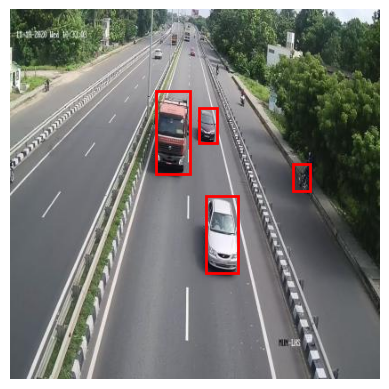

In [30]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# المسار الأساسي
base_img_path = "/kaggle/working/dataset/images/train"
base_label_path = "/kaggle/working/dataset/labels/train"

# اختيار صورة عشوائية من train
train_images = os.listdir(base_img_path)
img_name = train_images[3]  # أو random.choice(train_images) لاختيار عشوائي

img_file = os.path.join(base_img_path, img_name)
label_file = os.path.join(base_label_path, os.path.splitext(img_name)[0] + ".txt")

# قراءة الصورة
img = plt.imread(img_file)
plt.imshow(img)
plt.axis('off')

# رسم الـ bounding boxes إذا موجود
if os.path.exists(label_file):
    with open(label_file, 'r') as f:
        H, W, _ = img.shape
        for line in f.readlines():
            cls, x_center, y_center, w, h = map(float, line.strip().split())
            x = (x_center - w/2) * W
            y = (y_center - h/2) * H
            width = w * W
            height = h * H
            rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='r', facecolor='none')
            plt.gca().add_patch(rect)
else:
    print("No label file for:", img_name)

plt.show()


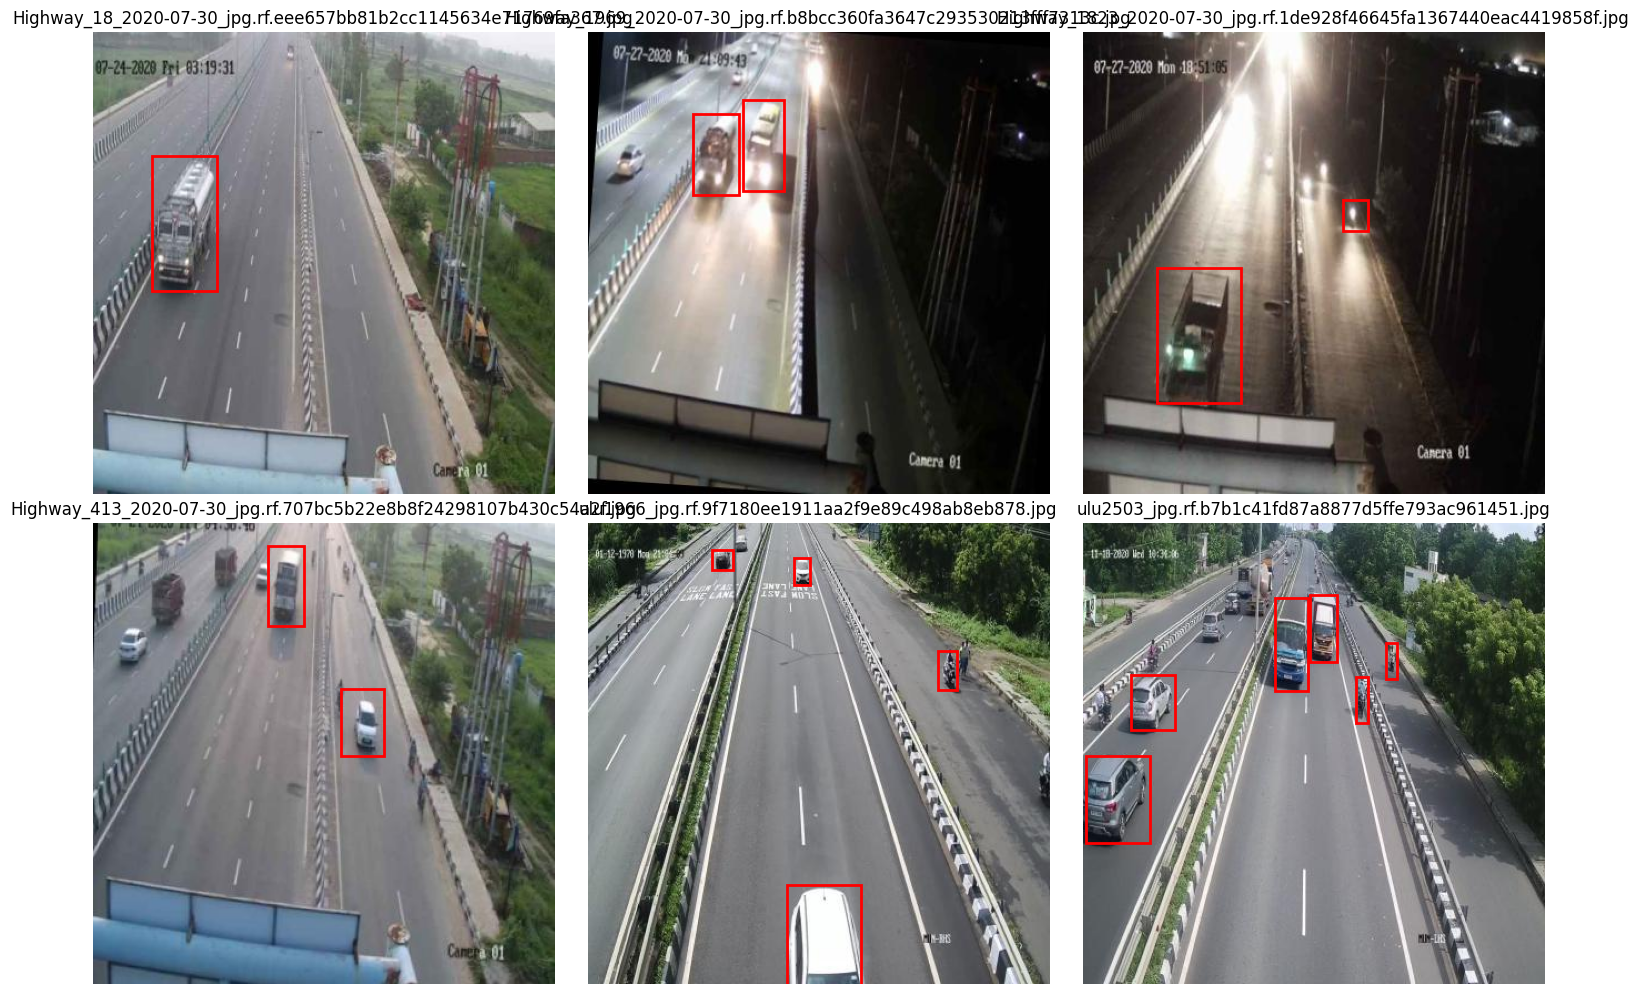

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import os

base_img_path = "/kaggle/working/dataset/images/train"
base_label_path = "/kaggle/working/dataset/labels/train"

train_images = os.listdir(base_img_path)
num_images = 6
selected_images = random.sample(train_images, num_images)

cols = 3
rows = (num_images + cols - 1) // cols
plt.figure(figsize=(15, 5 * rows))

for i, img_name in enumerate(selected_images):
    img_file = os.path.join(base_img_path, img_name)
    label_file = os.path.join(base_label_path, os.path.splitext(img_name)[0] + ".txt")
    img = plt.imread(img_file)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_name)

    if os.path.exists(label_file):
        H, W, _ = img.shape
        with open(label_file, 'r') as f:
            for line in f.readlines():
                cls, x_center, y_center, w, h = map(float, line.strip().split())
                x = (x_center - w/2) * W
                y = (y_center - h/2) * H
                width = w * W
                height = h * H
                rect = patches.Rectangle((x, y), width, height, linewidth=2, edgecolor='r', facecolor='none')
                plt.gca().add_patch(rect)

plt.tight_layout()
plt.show()


In [32]:
#Model Training Using YOLOv5 or YOLOv8

In [33]:
import os

os.makedirs("/kaggle/working/dataset", exist_ok=True)


In [34]:
data_yaml = """
path: /kaggle/working/dataset
train: images/train
val: images/val

nc: 8
names: ['car', 'bus', 'truck', 'motorbike', 'bicycle', 'van', 'scooter', 'other']
"""

with open("/kaggle/working/dataset/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created successfully")


data.yaml created successfully


In [35]:
# تثبيت YOLOv8
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.9 MB/s eta 0:00:00


In [36]:
import os

base_path = "/kaggle/working/dataset"
os.makedirs(os.path.join(base_path, "images/train"), exist_ok=True)
os.makedirs(os.path.join(base_path, "images/val"), exist_ok=True)
os.makedirs(os.path.join(base_path, "labels/train"), exist_ok=True)
os.makedirs(os.path.join(base_path, "labels/val"), exist_ok=True)


In [37]:
import shutil
import random

# المسار الأصلي للبيانات (اضبطه حسب Kaggle/Colab)
images_path = "/kaggle/input/vehicle-detection-8-classes-object-detection/train/images"
labels_path = "/kaggle/input/vehicle-detection-8-classes-object-detection/train/labels"

all_images = os.listdir(images_path)
random.shuffle(all_images)

split_ratio = 0.8
split_index = int(len(all_images) * split_ratio)

train_images = all_images[:split_index]
val_images = all_images[split_index:]

def copy_files(image_list, split_type):
    for img in image_list:
        shutil.copy(os.path.join(images_path, img), os.path.join(base_path, "images", split_type, img))
        label_file = os.path.splitext(img)[0] + ".txt"
        label_src = os.path.join(labels_path, label_file)
        label_dst = os.path.join(base_path, "labels", split_type, label_file)
        if os.path.exists(label_src):
            shutil.copy(label_src, label_dst)

copy_files(train_images, "train")
copy_files(val_images, "val")


In [38]:
!ls /kaggle/working/dataset/images/train | head
!ls /kaggle/working/dataset/images/val | head


Highway_0_2020-07-30_jpg.rf.09e9d4467f17b2b870a5d1b94a38774a.jpg
Highway_0_2020-07-30_jpg.rf.7d947cc31b302b22a527ecd17d3af963.jpg
Highway_0_2020-07-30_jpg.rf.f2b27ff74487ea9a91b9dff189180e8d.jpg
Highway_1000_2020-07-30_jpg.rf.9a2ce6acd2c0ffd57ab44a13f084b950.jpg
Highway_1000_2020-07-30_jpg.rf.e9364fb1c7d1bf9f8cbea3d1c1575050.jpg
Highway_1001_2020-07-30_jpg.rf.70c4d63695312c6c33bdd45d7638425b.jpg
Highway_1001_2020-07-30_jpg.rf.ced8d0ac9a9a09cd1ddbaa8c653008e8.jpg
Highway_1001_2020-07-30_jpg.rf.db743f57507e8e1864cd73c4c05a093a.jpg
Highway_100_2020-07-30_jpg.rf.420e2047f1190fd66d1da2b508d5caeb.jpg
Highway_100_2020-07-30_jpg.rf.ae0edfaa9c8b47db435cea200e7cfefc.jpg
Highway_1001_2020-07-30_jpg.rf.70c4d63695312c6c33bdd45d7638425b.jpg
Highway_100_2020-07-30_jpg.rf.c194e1c08f7f48551e2cc4511bcebd29.jpg
Highway_1002_2020-07-30_jpg.rf.38a72727824ebdf2c817a5e4be6daa0e.jpg
Highway_1003_2020-07-30_jpg.rf.654d2fe251045a4a37654a3e3ed4d2c6.jpg
Highway_1003_2020-07-30_jpg.rf.b14eddb12ef456c4b5b0721a6e995

In [39]:
#Yolo train
!yolo detect train \
    data=/kaggle/working/dataset/data.yaml \
    model=yolov8n.pt \
    epochs=50 \
    imgsz=640 \
    patience=5 \
    batch=16   \
    project=runs/train \
    name=best_model \
    save=True


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.242 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, ke


image 1/1 /kaggle/working/dataset/images/val/Highway_1184_2020-07-30_jpg.rf.d6585bf4339460b2c4d0b26f23639cea.jpg: 640x640 3 trucks, 1 bicycle, 1 other, 16.9ms
Speed: 5.5ms preprocess, 16.9ms inference, 17.8ms postprocess per image at shape (1, 3, 640, 640)


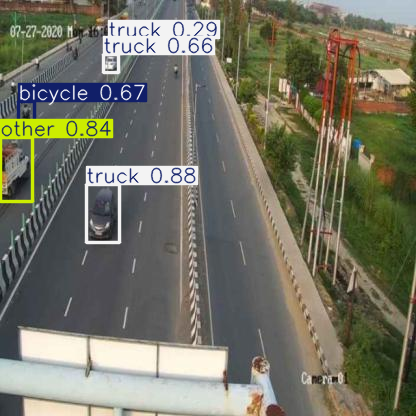

'prediction.jpg'

In [40]:
from ultralytics import YOLO
import os

model = YOLO("/content/runs/train/best_model/weights/best.pt")

img_path = "/kaggle/working/dataset/images/val/" + \
           os.listdir("/kaggle/working/dataset/images/val")[0]

results = model(img_path)
results[0].show()
results[0].save(filename="prediction.jpg")


In [41]:
model("/kaggle/working/dataset/images/val/", save=True)



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2945 /kaggle/working/dataset/images/val/Highway_1001_2020-07-30_jpg.rf.70c4d63695312c6c33bdd45d7638425b.jpg: 640x640 2 trucks, 9.8ms
image 2/2945 /kaggle/working/dataset/images/val/Highway_1002_2020-07-30_jpg.rf.38a72727824ebdf2c817a5e4be6daa0e.jpg: 640x640 1 truck, 2 bicycles, 7.7ms
image 3/2945 /kaggle/working/dataset/images/val/Highway_1003_2020-07-30_jpg.rf.654d2fe251045a4a37654a3e3ed4d2c6.jpg: 640x640 1 motorbike, 1 other, 7.1ms
image 4/2945

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'bus', 2: 'truck', 3: 'motorbike', 4: 'bicycle', 5: 'van', 6: 'scooter', 7: 'other'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0,

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

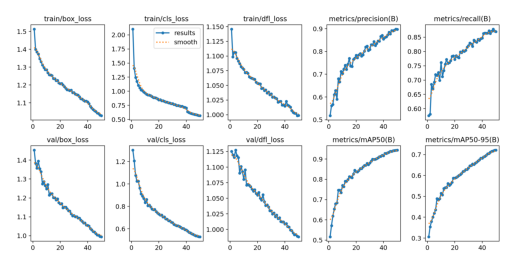

In [42]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/train/best_model/results.png")
plt.imshow(img)
plt.axis("off")

In [43]:

#Evaluating model performance

from ultralytics import YOLO


# Load the trained model
model = YOLO('runs/train/best_model/weights/best.pt')


In [44]:
# Evaluate on validation/test set

data_yaml = """
path: /kaggle/working/dataset
train: images/train
val: images/val

nc: 8
names: ['car', 'bus', 'truck', 'motorbike', 'bicycle', 'van', 'scooter', 'other']
"""

with open("/kaggle/working/dataset/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created successfully")

data.yaml created successfully


In [45]:
model = YOLO('runs/train/best_model/weights/best.pt')

# Evaluate on validation set
metrics = model.val(data='/kaggle/working/dataset/data.yaml')

# Print evaluation metrics
print(metrics)


Ultralytics 8.3.242 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 946.0±271.2 MB/s, size: 24.8 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 2945 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2945/2945 4.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 185/185 6.4it/s 29.0s
                   all       2945       9346      0.898      0.868      0.944      0.722
                   car        276        308        0.9      0.902      0.965      0.675
                   bus        416        451      0.898       0.88      0.945      0.774
                 truck       2082       4083      0.941      0.915      0.975      0.725
             motorbike        334        351      0.888      0.746      0.891      0.722
               bicycle       1487       

In [46]:
!ls runs/train/

best_model


In [47]:
# Real-time Detection

from ultralytics import YOLO
from collections import Counter
import cv2
import os

# 1️⃣ التحقق من وجود النموذج
best_model_path = 'runs/train/best_model/weights/best.pt'
last_model_path = 'runs/train/best_model/weights/last.pt'

if os.path.exists(best_model_path):
    model_path = best_model_path
elif os.path.exists(last_model_path):
    model_path = last_model_path
    print("Best model not found. Using last.pt instead.")
else:
    raise FileNotFoundError("Neither best.pt nor last.pt found. تحقق من مسار النموذج!")

# 2️⃣ تحميل النموذج
model = YOLO(model_path)

# 3️⃣ أسماء الفئات
class_names = ['car', 'bus', 'truck', 'motorbike', 'bicycle', 'van', 'scooter', 'other']

# 4️⃣ فتح الكاميرا
cap = cv2.VideoCapture(0)  # 0 للكاميرا الافتراضية

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 5️⃣ تشغيل التنبؤ على كل فريم
    results = model.predict(frame, verbose=False)

    # 6️⃣ رسم الصناديق على الفريم
    annotated_frame = results[0].plot()  # صورة مع bounding boxes

    # 7️⃣ عد الأجسام
    counts = Counter(results[0].boxes.cls.tolist())
    counts_named = {class_names[k]: v for k, v in counts.items()}

    # عرض عد الأجسام على الشاشة
    y = 30
    for cls, cnt in counts_named.items():
        cv2.putText(annotated_frame, f"{cls}: {cnt}", (10, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        y += 30

    # 8️⃣ عرض الفريم
    cv2.imshow("YOLOv8 Real-Time Detection", annotated_frame)

    # 9️⃣ الخروج بالضغط على 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# تحرير الكاميرا وإغلاق النوافذ
cap.release()
cv2.destroyAllWindows()


In [48]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        if file == "best.pt":
            print(os.path.join(root, file))


In [1]:
!pip install gradio ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.4 MB/s eta 0:00:00


In [2]:
import gradio as gr
import cv2
import tempfile
import os
from ultralytics import YOLO

#  تحميل النموذج
MODEL_PATH = "/content/runs/train/best_model/weights/best.pt"
model = YOLO(MODEL_PATH)


# ===============================
#  Image Detection Function
# ===============================
def detect_image(image):
    results = model(image)
    annotated_img = results[0].plot()
    return annotated_img


# ===============================
#  Video Detection Function
# ===============================
def detect_video(video):
    cap = cv2.VideoCapture(video)

    temp_out = tempfile.NamedTemporaryFile(delete=False, suffix=".mp4")
    output_path = temp_out.name

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame)
        annotated_frame = results[0].plot()
        out.write(annotated_frame)

    cap.release()
    out.release()

    return output_path


# ===============================
#  Gradio Interface
# ===============================
with gr.Blocks(title="YOLOv8 Vehicle Detection") as demo:

    gr.Markdown("## 🚗 YOLOv8 Vehicle Detection GUI")
    gr.Markdown("Upload an image or video to detect vehicles using YOLOv8.")

    with gr.Tab("Image Detection"):
        img_input = gr.Image(type="numpy", label="Upload Image")
        img_output = gr.Image(label="Detection Result")
        img_btn = gr.Button("Detect")
        img_btn.click(detect_image, inputs=img_input, outputs=img_output)

    with gr.Tab("Video Detection"):
        vid_input = gr.Video(label="Upload Video")
        vid_output = gr.Video(label="Detection Result")
        vid_btn = gr.Button("Detect")
        vid_btn.click(detect_video, inputs=vid_input, outputs=vid_output)

demo.launch(share=True)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/train/best_model/weights/best.pt'

In [51]:
import os
print(os.listdir("/kaggle/working/runs/train/"))
print(os.listdir("/kaggle/working/runs/train/best_model/weights/"))


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/runs/train/'

In [ ]:
!zip -r runs_results.zip runs

In [ ]:
from google.colab import files
files.download("runs_results.zip")